# Imports

In [73]:
import numpy as np
from sklearn.datasets import load_diabetes

#diabetes dataset

In [74]:
X,y = load_diabetes(return_X_y=True)

In [75]:
X

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]])

In [76]:
X.shape

(442, 10)

In [51]:
y

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59., 104., 182.,
       128.,  52.,  37., 170., 170.,  61., 144.,  52., 128.,  71., 163.,
       150.,  97., 160., 178.,  48., 270., 202., 111.,  85.,  42., 170.,
       200., 252., 113., 143.,  51.,  52., 210.,  65., 141.,  55., 134.,
        42., 111.,  98., 164.,  48.,  96.,  90., 162., 150., 279.,  92.,
        83., 128., 102., 302., 198.,  95.,  53., 134., 144., 232.,  81.,
       104.,  59., 246., 297., 258., 229., 275., 281., 179., 200., 200.,
       173., 180.,  84., 121., 161.,  99., 109., 115., 268., 274., 158.,
       107.,  83., 103., 272.,  85., 280., 336., 281., 118., 317., 235.,
        60., 174., 259., 178., 128.,  96., 126., 28

In [52]:
y.shape

(442,)

## Using Sklearn's Linear Regression

In [53]:
from sklearn.model_selection import train_test_split

In [54]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [55]:
print(X_train.shape)
print(X_test.shape)

(353, 10)
(89, 10)


In [56]:
from sklearn.linear_model import LinearRegression

In [57]:
reg = LinearRegression()

In [58]:
reg.fit(X_train,y_train)

LinearRegression()

In [59]:
y_pred = reg.predict(X_test)

In [60]:
from sklearn.metrics import r2_score

In [61]:
r2_score(y_test,y_pred)

0.4399338661568968

In [62]:
reg.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [63]:
reg.intercept_

np.float64(151.88331005254167)

## Making our own Linear Regression Class

betas = <br>
np.linalg.<br>
inv(np.dot(X_train.T,X_train))<br>
.dot(X_train.T)<br>
.dot(y_train)<br>

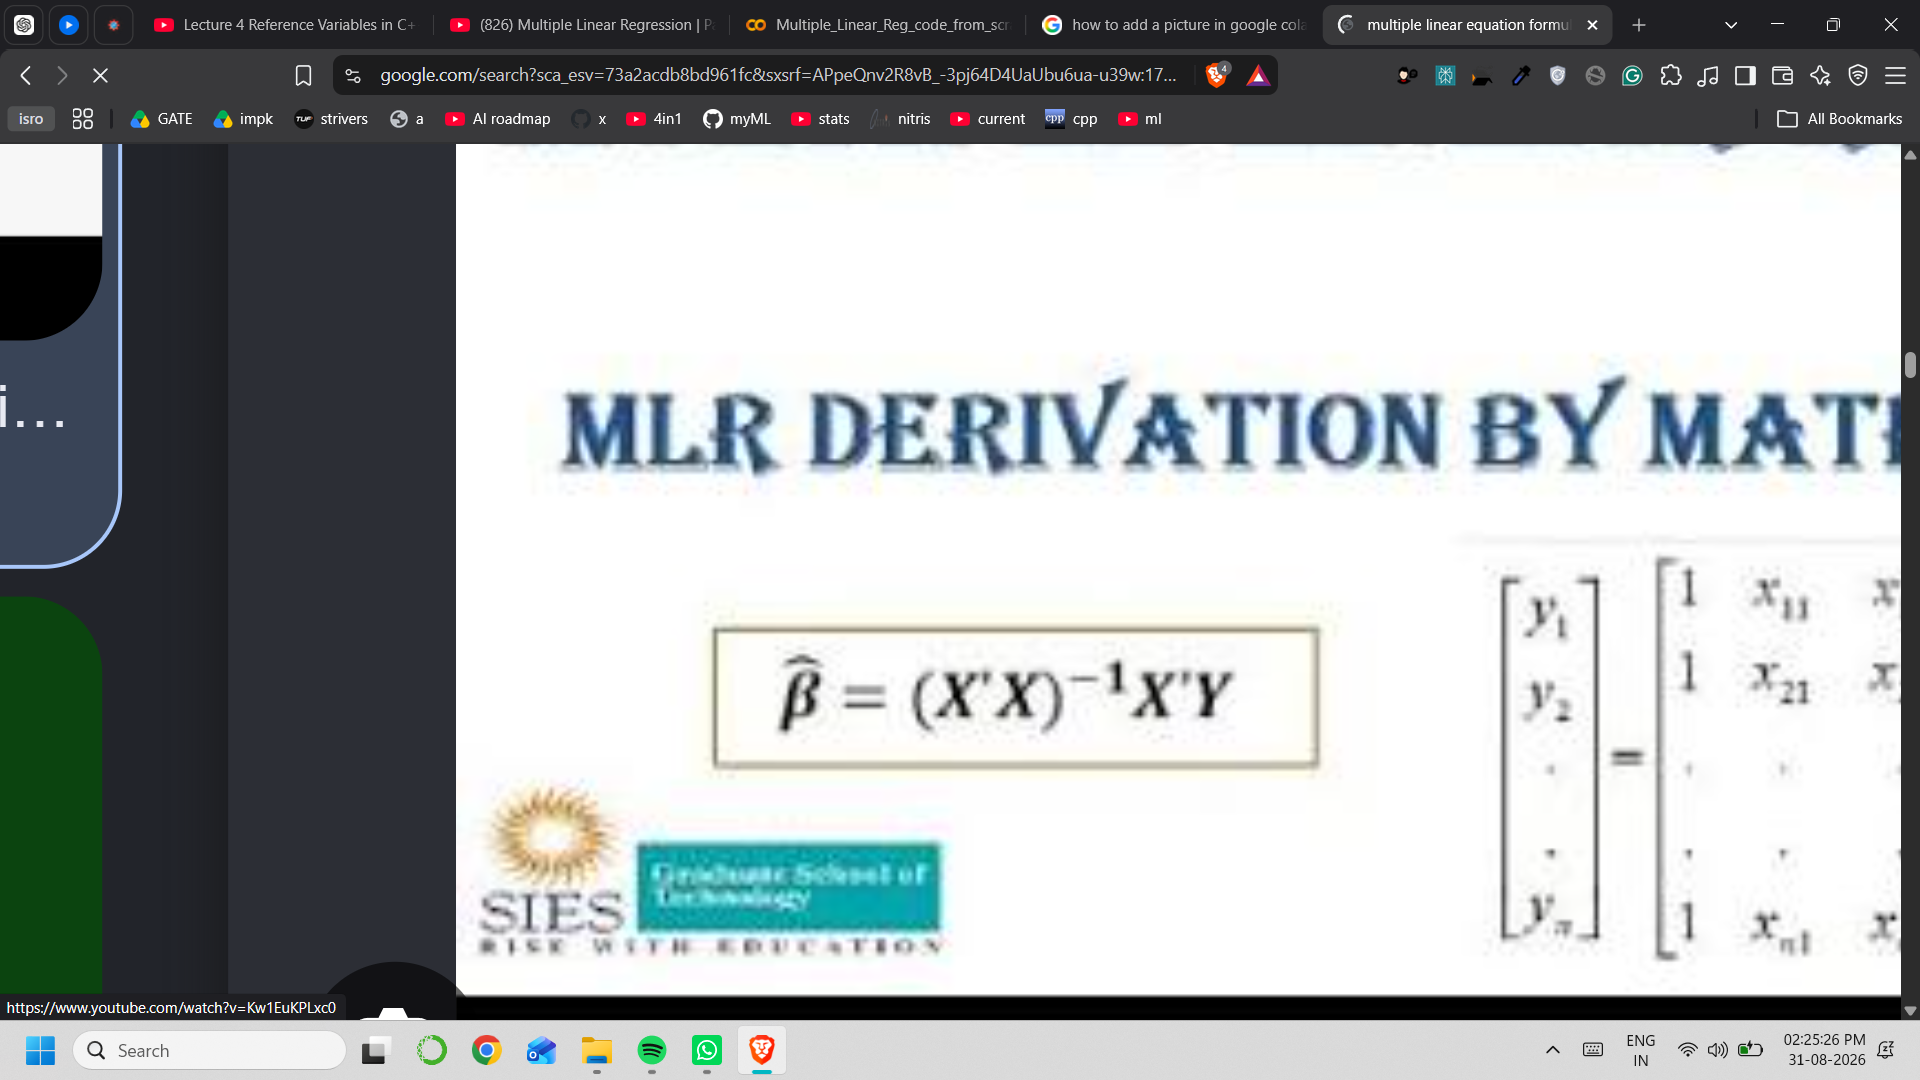

In [64]:
class MeraLR:

    def __init__(self):
        self.coef_ = None
        self.intercept_ = None

    def fit(self,X_train,y_train):
        X_train = np.insert(X_train,0,1,axis=1)  # adding a column (beta 0) at index 0

        # calcuate the coeffs
        betas = np.linalg.inv(np.dot(X_train.T,X_train)).dot(X_train.T).dot(y_train)
        self.intercept_ = betas[0]
        self.coef_ = betas[1:]

    def predict(self,X_test):
        y_pred = np.dot(X_test,self.coef_) + self.intercept_
        return y_pred



In [65]:
lr = MeraLR()

In [66]:
lr.fit(X_train,y_train)

In [67]:
X_train.shape

(353, 10)

In [68]:
np.insert(X_train,0,1,axis=1).shape

(353, 11)

In [69]:
y_pred = lr.predict(X_test)

In [70]:
r2_score(y_test,y_pred)

0.43993386615689634

#compare coef_

In [71]:
lr.coef_,reg.coef_

(array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
        -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
         861.12700152,   52.42112238]),
 array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
        -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
         861.12700152,   52.42112238]))

#compare intercept_

In [72]:
lr.intercept_,reg.intercept_

(np.float64(151.88331005254165), np.float64(151.88331005254167))